# 02 — EDA: justifying the OKF + slim-parquet approach

A structured exploratory data analysis of the CDC NHIS 2023 Sample Adult file, following the
canonical EDA arc — **Collection & Cleaning → Exploration → Visualization → Feature Engineering
→ Hypothesis Testing → Conclusion** — but for *complex-survey* data, where the rules are
stricter (weights are mandatory, and skip-patterns define the universe).

The goal is not a model. It is to let the data **justify the pipeline** in article 2: why
verification must *run* the weighted analysis (not lint), what the OKF concepts should be, and
which columns the slim parquet keeps. Every finding maps to a decision the `okf_pipeline` encodes.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7.5, 4.2)
TEAL, GREY, RED, BLUE = "#2a9d8f", "#c9c9c9", "#e76f51", "#264653"

CANDIDATES = [os.environ.get("NHIS_CSV"), "../../nhis-okf-compiler/data/adult23.csv",
              "../nhis-okf-compiler/data/adult23.csv", "data/adult23.csv"]
CSV = next((p for p in CANDIDATES if p and Path(p).exists()), None)
assert CSV, "Set NHIS_CSV to the NHIS 2023 adult public-use CSV (adult23.csv)."

# The diabetes slice — the only columns this analysis needs out of 647.
SLICE = ["DIBEV_A", "DIBINS_A", "PREDIB_A", "DIBAGETC_A", "SEX_A", "WTFA_A", "PSTRAT", "PPSU"]
CODES = {"DIBEV_A": "diagnosed diabetes (1=yes)", "DIBINS_A": "takes insulin (1=yes)",
         "PREDIB_A": "prediabetes (1=yes)", "DIBAGETC_A": "age at diagnosis (top-coded)",
         "SEX_A": "sex (1=M, 2=F)", "WTFA_A": "final annual weight", "PSTRAT": "design stratum",
         "PPSU": "design PSU"}
df_full = pd.read_csv(CSV, low_memory=False)
df = df_full[SLICE].copy()
print(f"{CSV}: {df_full.shape[0]:,} sample adults × {df_full.shape[1]} columns "
      f"→ working with the {len(SLICE)}-column diabetes slice")

../../nhis-okf-compiler/data/adult23.csv: 29,522 sample adults × 647 columns → working with the 8-column diabetes slice


## 1. Data collection & cleaning

The data is the CDC NHIS 2023 public-use file (public domain). "Cleaning" for a survey means one
specific thing: **non-substantive codes are not answers.** Yes/no items are coded 1/2; 7/8/9 are
Refused / Not Ascertained / Don't Know, and blanks mean *not in this question's universe*. All of
those must be dropped from any denominator (skill rule 3). First, a numeric overview:

In [2]:
df[["DIBAGETC_A", "WTFA_A"]].describe().T

,count,mean,std,min,25%,50%,75%,max
DIBAGETC_A,3294.0,51.163024,17.975938,1.000,40.00000,51.000,61.0000,99.0
WTFA_A,29522.0,8747.291918,5690.650182,1792.441,4643.53175,7374.546,10994.8095,39925.6


The yes/no items look "complete" only if you ignore what the codes mean. Chart the raw response
mix per item — how much of each column is a real answer vs. non-substantive vs. not-asked:

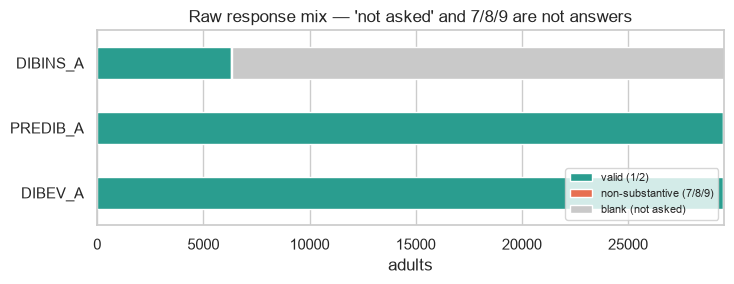

Only DIBINS_A has large 'not asked' — the tell of a skip-pattern (explored next).


In [3]:
def classify(s):
    return pd.Series({"valid (1/2)": s.isin([1, 2]).sum(),
                      "non-substantive (7/8/9)": s.isin([7, 8, 9]).sum(),
                      "blank (not asked)": s.isna().sum()})

mix = df[["DIBEV_A", "PREDIB_A", "DIBINS_A"]].apply(classify).T
mix.plot(kind="barh", stacked=True, color=[TEAL, RED, GREY], figsize=(7.5, 3))
plt.title("Raw response mix — 'not asked' and 7/8/9 are not answers")
plt.xlabel("adults"); plt.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()
print("Only DIBINS_A has large 'not asked' — the tell of a skip-pattern (explored next).")

## 2. Data exploration

Distributions of the slice, then the structural fact that drives everything: **`DIBINS_A` is only
asked of a subgroup.** We confirm the universe *empirically* — who actually has a valid answer —
not from the variable name (skill rule 2).

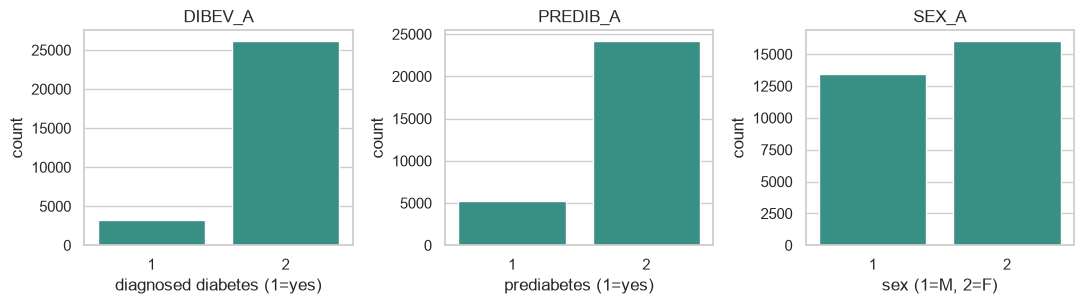

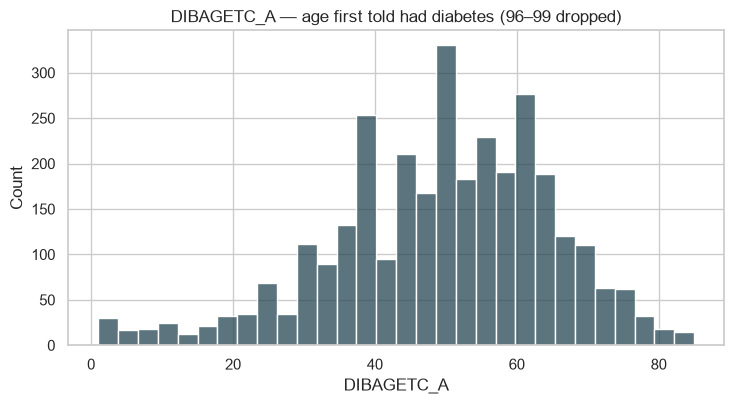

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, col in zip(ax, ["DIBEV_A", "PREDIB_A", "SEX_A"]):
    sns.countplot(x=df[col][df[col].isin([1, 2])].astype(int), ax=a, color=TEAL)
    a.set_title(col); a.set_xlabel(CODES[col])
plt.tight_layout(); plt.show()

age = df.loc[df["DIBAGETC_A"].between(0, 95), "DIBAGETC_A"]  # drop 96-99 top/non-substantive
sns.histplot(age, bins=30, color=BLUE)
plt.title("DIBAGETC_A — age first told had diabetes (96–99 dropped)"); plt.tight_layout(); plt.show()

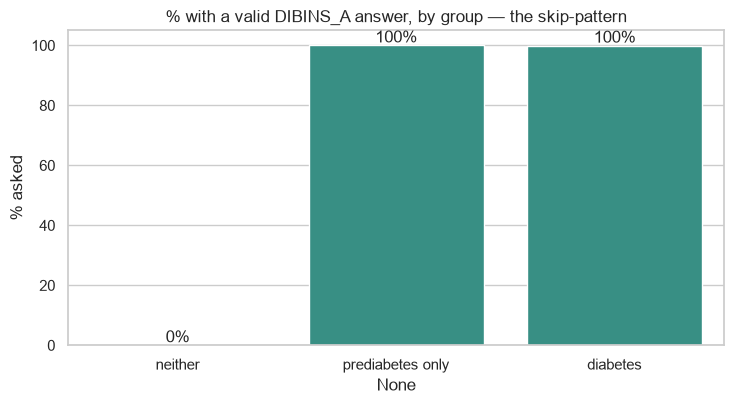

valid answers ⊆ (diabetes|prediabetes): True  → question universe is empirical, not from the name.


In [5]:
# The skip-pattern, empirically: % with a valid DIBINS_A answer, by diabetes/prediabetes group.
grp = np.select([df["DIBEV_A"] == 1, (df["PREDIB_A"] == 1) & (df["DIBEV_A"] != 1)],
                ["diabetes", "prediabetes only"], default="neither")
asked = df.groupby(grp)["DIBINS_A"].apply(lambda s: s.isin([1, 2]).mean() * 100)
asked = asked.reindex(["neither", "prediabetes only", "diabetes"])
ax = sns.barplot(x=asked.index, y=asked.values, hue=asked.index,
                 palette=[GREY, TEAL, TEAL], legend=False)
for i, v in enumerate(asked.values):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.title("% with a valid DIBINS_A answer, by group — the skip-pattern"); plt.ylabel("% asked")
plt.tight_layout(); plt.show()
valid = df["DIBINS_A"].isin([1, 2]); universe = (df["DIBEV_A"] == 1) | (df["PREDIB_A"] == 1)
print(f"valid answers ⊆ (diabetes|prediabetes): {bool((valid & ~universe).sum() == 0)}  "
      f"→ question universe is empirical, not from the name.")

## 3. Visualization — the feature-to-feature relationship

A correlation/relationship view (the reference's "feature to feature"): the crosstab of diabetes
status × insulin makes the skip-pattern *structural* — insulin is only ever answered within the
diabetes/prediabetes rows. This is why "% over the whole sample" is meaningless.

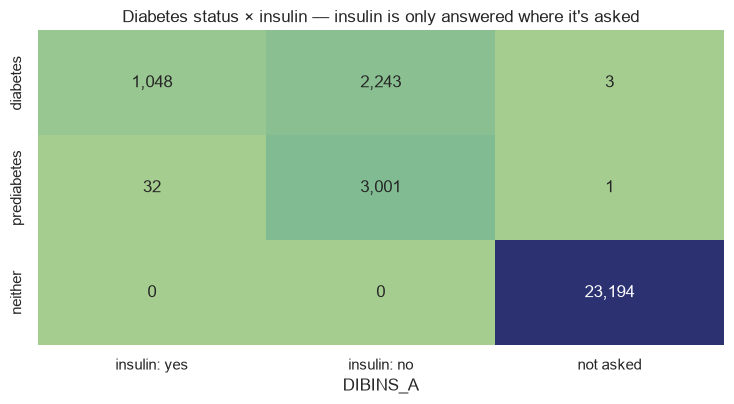

In [6]:
ct = pd.crosstab(np.select([df["DIBEV_A"] == 1, df["PREDIB_A"] == 1], ["diabetes", "prediabetes"],
                           "neither"),
                 df["DIBINS_A"].map({1: "insulin: yes", 2: "insulin: no"}).fillna("not asked"))
ct = ct.reindex(index=["diabetes", "prediabetes", "neither"],
                columns=["insulin: yes", "insulin: no", "not asked"])
sns.heatmap(ct, annot=True, fmt=",", cmap="crest", cbar=False)
plt.title("Diabetes status × insulin — insulin is only answered where it's asked")
plt.ylabel(""); plt.tight_layout(); plt.show()

## 4. Feature engineering — from raw columns to OKF concepts

"Feature engineering" here = turning raw survey columns into the **analysis-ready features** the
pipeline publishes: an empirically-confirmed universe, a survey-weighted estimator, and the slim
column set. First the estimator (weights mandatory — skill rule 1), then the concept table.

In [7]:
def wpct(mask, var, aff=1, weight="WTFA_A"):
    """Survey-weighted % answering `aff` for `var` within `mask` (valid 1/2 only)."""
    v = df[mask & df[var].isin([1, 2])]
    return v.loc[v[var] == aff, weight].sum() / v[weight].sum() * 100

all_adults = pd.Series(True, index=df.index)
concepts = [("DIBEV_A", "", "diagnosed diabetes prevalence"),
            ("PREDIB_A", "", "prediabetes prevalence"),
            ("DIBINS_A", "DIBEV_A == 1", "insulin use among diagnosed diabetics")]
concept_table = pd.DataFrame([
    {"concept": v, "universe": u or "(all adults)", "weight": "WTFA_A",
     "value_pct": round(wpct(df.eval(u) if u else all_adults, v), 2), "claim": t}
    for v, u, t in concepts])
print(concept_table.to_string(index=False))

 concept     universe weight  value_pct                                 claim
 DIBEV_A (all adults) WTFA_A       9.80         diagnosed diabetes prevalence
PREDIB_A (all adults) WTFA_A      16.07                prediabetes prevalence
DIBINS_A DIBEV_A == 1 WTFA_A      31.96 insulin use among diagnosed diabetics


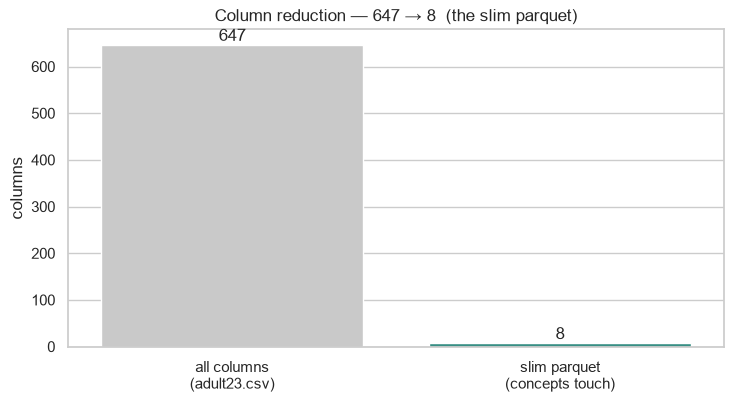

kept: DIBEV_A, DIBINS_A, PREDIB_A, DIBAGETC_A, SEX_A, WTFA_A, PSTRAT, PPSU


In [8]:
# The slim parquet: only the columns these concepts (+ survey design + a grouping col) touch.
_labels = ["all columns\n(adult23.csv)", "slim parquet\n(concepts touch)"]
ax = sns.barplot(x=_labels, y=[df_full.shape[1], len(SLICE)], hue=_labels,
                 palette=[GREY, TEAL], legend=False)
for i, v in enumerate([df_full.shape[1], len(SLICE)]):
    ax.text(i, v + 8, str(v), ha="center")
plt.title(f"Column reduction — {df_full.shape[1]} → {len(SLICE)}  (the slim parquet)")
plt.ylabel("columns"); plt.tight_layout(); plt.show()
print("kept:", ", ".join(SLICE))

## 5. Hypothesis testing — is the naive number a plausible population value?

The claim is *"% of diagnosed diabetics currently taking insulin."* Four reasonable-looking
recipes give four different numbers. Treat it as a test: **compute the correct weighted estimate
with a design-based 95% CI** (Taylor linearization over the survey strata/PSUs — the skill's
"documented upgrade"), and check whether the other recipes fall inside it. If a recipe lands far
outside the CI, it is *rejected* as an estimate of the population parameter.

CORRECT estimate: 31.96%  (95% CI 30.08–33.84;  design-based SE 0.96pp)


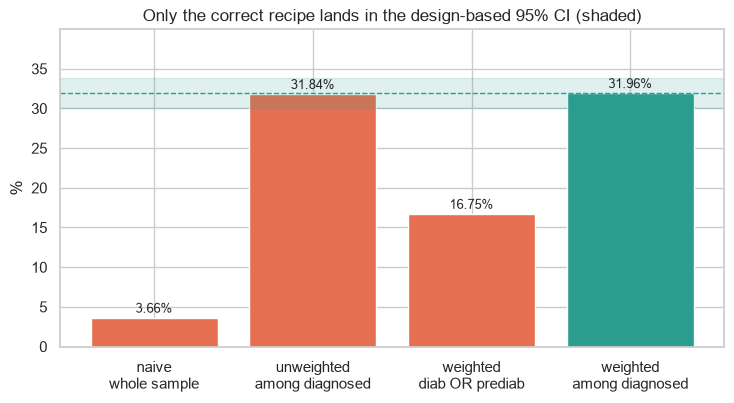

  naive whole sample                3.66%  ❌ REJECTED (outside CI)
  unweighted among diagnosed       31.84%  ✅ inside CI
  weighted diab OR prediab         16.75%  ❌ REJECTED (outside CI)
  weighted among diagnosed         31.96%  ✅ inside CI


In [9]:
def design_ci(mask, var, aff=1, weight="WTFA_A", strat="PSTRAT", psu="PPSU"):
    """Weighted proportion + design-based 95% CI via Taylor linearization (stratified PSU var)."""
    d = df[mask & df[var].isin([1, 2])].copy()
    w, y = d[weight], (d[var] == aff).astype(float)
    p = (w * y).sum() / w.sum()
    d["_z"] = w * (y - p) / w.sum()                       # linearized residual of the ratio est.
    v = 0.0
    for _, g in d.groupby(strat):                          # stratified PSU-total variance
        tot = g.groupby(psu)["_z"].sum()
        if len(tot) > 1:
            v += len(tot) / (len(tot) - 1) * ((tot - tot.mean()) ** 2).sum()
    se = v ** 0.5
    return p * 100, (p - 1.96 * se) * 100, (p + 1.96 * se) * 100, se * 100

diag = df["DIBEV_A"] == 1
p, lo, hi, se = design_ci(diag, "DIBINS_A")
print(f"CORRECT estimate: {p:.2f}%  (95% CI {lo:.2f}–{hi:.2f};  design-based SE {se:.2f}pp)")

recipes = {
    "naive\nwhole sample": (df["DIBINS_A"] == 1).sum() / len(df) * 100,
    "unweighted\namong diagnosed": df.loc[diag & df["DIBINS_A"].isin([1, 2]), "DIBINS_A"].eq(1).mean() * 100,
    "weighted\ndiab OR prediab": wpct((df["DIBEV_A"] == 1) | (df["PREDIB_A"] == 1), "DIBINS_A"),
    "weighted\namong diagnosed": p,
}
fig, ax = plt.subplots()
bars = ax.bar(list(recipes), list(recipes.values()),
              color=[RED, RED, RED, TEAL])
ax.axhspan(lo, hi, color=TEAL, alpha=0.15)                # the 95% CI band of the correct estimate
ax.axhline(p, color=TEAL, ls="--", lw=1)
for b, v in zip(bars, recipes.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_title("Only the correct recipe lands in the design-based 95% CI (shaded)")
ax.set_ylabel("%"); ax.set_ylim(0, max(recipes.values()) * 1.25); plt.tight_layout(); plt.show()

for name, val in recipes.items():
    inside = lo <= val <= hi
    print(f"  {name.replace(chr(10),' '):32} {val:5.2f}%  "
          f"{'✅ inside CI' if inside else '❌ REJECTED (outside CI)'}")

The naive whole-sample rate and the wrong-universe rate fall **far outside** the confidence
interval of the correct estimate — they are not plausible values for the population parameter.
The unweighted-among-diagnosed rate is close but the weight still moves it. Statistically, the
recipe you pick is *not* cosmetic — which is precisely what a lint can't see and a run can.

## 6. Conclusion — the EDA justifies the pipeline

| EDA finding | Pipeline decision it justifies |
| --- | --- |
| 7/8/9/blank are not answers (§1) | `verify` drops non-substantive codes |
| `DIBINS_A` universe is empirical (§2–3) | concepts carry an explicit `universe`, confirmed against data |
| naive/wrong-universe rates are rejected by the CI (§5) | verification must **run** the weighted analysis — the gate |
| 647 → 8 columns (§4) | `slim` (duckdb) ships only what the concepts touch |

A concept that gets any of these wrong — like the seeded naive 3.66% — is *structurally* clean
but *statistically* wrong. That gap is the entire reason the pipeline has an execution-grounded
gate instead of a link-checker. On to building it (article 2, §3–§6).